# PMoA selection for 2,4-D in *D. galganoi*

We fitted TKTD models for *D. galganoi* and 2,4D based on three alternative PMoAs (G, M, A). <br>
The PMoA R was omitted because we are only dealing with larval and metamorph data. <br>
The PMoA $\kappa^-$ (decrease in $\kappa$) was omitted because metamorphosis was clearly delayed as a function of 2,4D-exposure.<br>

We apply three model selection methods:

- Visual inspection: comparing goodness-of-fit
- Bayesian model selection: calculating posterior probabilities based on likelihood-free Bayesian methods
- Frequentist model selection: comparing minimized loss values

## Notebook setup

In [ ]:
using DrWatson
@quickactivate "."
using Pkg; Pkg.instantiate()

In [3]:
using Revise

const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG = "Discoglossus_24D"

using Revise

includet(scriptsdir("ModelFitting_Discoglossus_24D_UCLM.jl")) 

## Visual inspection

The code below extract the best fit (parameter sample with lowest loss) for each PMoA, 
and evaluates it repeatedly. <br>
The repeated evaluation is done to account for model stochasticity. <br>
Note that, since we evaluate identical parameters repeatedly, the resulting prediction intervals do *not* indicate parameter uncertainty.

In [4]:
"""
    p_opt_from_tag(savetag::AbstractString)

Read best-fitting parameter combination from a posterior_summary.csv file.
"""
function p_opt_from_tag(savetag::AbstractString)

    posterior_summary = CSV.read(datadir("sims", savetag, "posterior_summary.csv"), DataFrame)
    return posterior_summary.best_fit

end

# read best fits for alternative PMoA
p_opt_G = p_opt_from_tag(joinpath("Discoglossus_24D_2025-06-23_numtadpoles", "Discoglossus_24D_G"))
p_opt_M = p_opt_from_tag(joinpath("Discoglossus_24D_2025-06-23_numtadpoles", "Discoglossus_24D_M"))
p_opt_A = p_opt_from_tag(joinpath("Discoglossus_24D_2025-06-23_numtadpoles", "Discoglossus_24D_A"));

In [5]:
# run simulations for alternative PMoAs

n = 100

fG = setup_modelfit("G")
sim_opt_G = [fG.simulator(p_opt_G) for _ in 1:n]

fM = setup_modelfit("M")
sim_opt_M = [fM.simulator(p_opt_M) for _ in 1:n]

fA = setup_modelfit("A")
sim_opt_A = [fA.simulator(p_opt_A) for _ in 1:n];

┌ Info: Overwriting default values of String31["spc.Z", "spc.dI_max_lrv", "spc.k_M_emb", "spc.eta_AS_emb", "spc.H_j1", "spc.gamma", "spc.k_J_emb", "spc.kappa_emb", "spc.watercontent_larvae", "spc.watercontent_juveniles", "spc.time_since_birth"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\scripts\ModelFitting_Discoglossus_24D_UCLM.jl:228
┌ Info: Overwriting default values of String15["spc.dI_max_juv", "spc.eta_AS_juv", "spc.H_p", "spc.k_J_juv", "spc.eta_AR"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\scripts\ModelFitting_Discoglossus_24D_UCLM.jl:237
┌ Info: 
│         Estimating 3 parameters: 
│         ["spc.KD[1,1]", "spc.E[1,1]", "spc.B[1,1]"]
│         
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found in data key a

PMoAs $M$ and $A$ can explain the data well, since they can simultaneously match reduction in growth and delay in metamorphosis appropriately. <br>
$G$ appears unlikely, since the delay in metamorphosis is under-estimated.

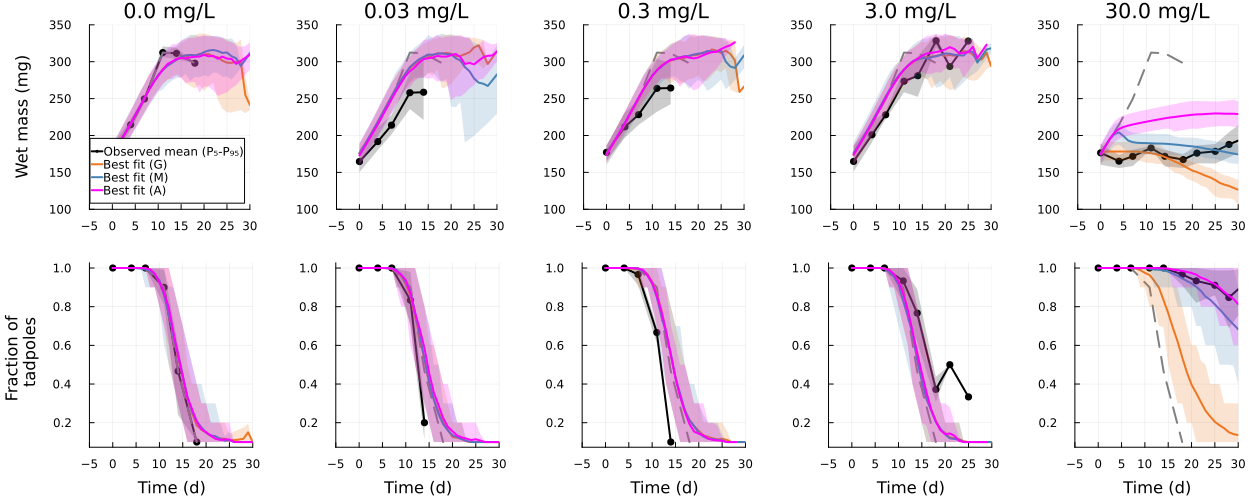

In [7]:
f = fG; plt = plot_data()

plot_sims!(plt, sim_opt_G, label = "Best fit (G)", color = :chocolate2)
plot_sims!(plt, sim_opt_M, label = "Best fit (M)", color = :steelblue)
plot_sims!(plt, sim_opt_A, label = "Best fit (A)", color = :magenta)
#plot!(subplot = 1, xlim = (0,20))
#plot!(subplot = 2, xlim = (0,15))

savefig(plot(plt, dpi = 400), plotsdir("Discoglossus_24D_summaries_PMoA_comparison.png"))

plt

## Estimating model probabilities

Here, we attempt to estimate posterior probabilities for alternative PMoAs, by subjecting accepted parameters from different PMoAs to the same rejection threshold 
and normalizing the frequency at which they are accepted [(cf. van der Vaart et al., 2015)](https://www.sciencedirect.com/science/article/pii/S0304380015002173). <br>
By performing this operation repeatedly on bootstrap samples of the accepted parameters, we can calculate credible intervals of the posterior probabilities. This is helpful to judge whether a given difference in probabilities is meaningful.

In [11]:
"""
    accepted_from_tag(savetag::AbstractString)

Read accepted samples from a file.
"""
function accepted_from_tag(savetag::AbstractString)

    accepted = CSV.read(datadir("sims", savetag, "accepted.csv"), DataFrame)
    
    return accepted

end

accepted_G = accepted_from_tag(joinpath("Discoglossus_24D_2025-06-23_numtadpoles", "Discoglossus_24D_G")) 
accepted_M = accepted_from_tag(joinpath("Discoglossus_24D_2025-06-23_numtadpoles", "Discoglossus_24D_M"))
accepted_A = accepted_from_tag(joinpath("Discoglossus_24D_2025-06-23_numtadpoles", "Discoglossus_24D_A"));

In [12]:
# calculate posterior probabilities based on rejection approach

accepted_G[!,:model] .= "G"
accepted_M[!,:model] .= "M"
accepted_A[!,:model] .= "A"

losses = vcat(
    accepted_G[:,[:model,:loss, :weight]],
    accepted_M[:,[:model,:loss, :weight]],
    accepted_A[:,[:model,:loss, :weight]]
)

ϵ = quantile(losses.loss, 0.25)

losses_accepted = @subset(losses, :loss .<= ϵ)

probs = countmap(losses_accepted.model) |> OrderedDict |>
x -> DataFrame(model = x.keys, prob = x.vals ./ sum(values(x)))

for model in ["G", "M", "A"] # add 0s for entirely rejected models
    if !(model in probs.model)
        append!(probs, DataFrame(
            model = model, 
            prob = 0.
        ))
    end
end

probs

Row,model,prob
,String,Float64
1,A,0.826667
2,M,0.106667
3,G,0.0666667


In [ ]:
# calculate errors of posterior probabilities using bootstrapping

bootstrap_samplesize = Int(0.5*nrow(losses))
n_samples = 1000

bootstrap_probs_G = []
bootstrap_probs_A = []
bootstrap_probs_M = []

for i in 1:n_samples

    bootstrap_idxs = sample(1:nrow(losses), bootstrap_samplesize)

    losses_i = losses[bootstrap_idxs,:] # get re-sampled subset of losses
    epsilon = quantile(losses_i.loss, 0.25) # compute the threshold for the bootstrap sample

    acc = @subset(losses_i, :loss .<= epsilon, :weight .> 0)

    probs_i = countmap(acc.model) |> OrderedDict |>
    x -> DataFrame(model = x.keys, prob = x.vals ./ sum(values(x)))

    # add 0s for entirely rejected models
    for model in ["G", "M", "A"] 
        if !(model in probs_i.model)
            append!(probs_i, DataFrame(
                model = model, 
                prob = 0.
            ))
        end
    end

    sort!(probs_i, :model)

    push!(bootstrap_probs_A, probs_i.prob[1])
    push!(bootstrap_probs_G, probs_i.prob[2])
    push!(bootstrap_probs_M, probs_i.prob[3])

end

According to this (rudimentary) Bayesian model selection, PMoA $A$ has the highest posterior probability, folowed by $M$ and $G$. <br>

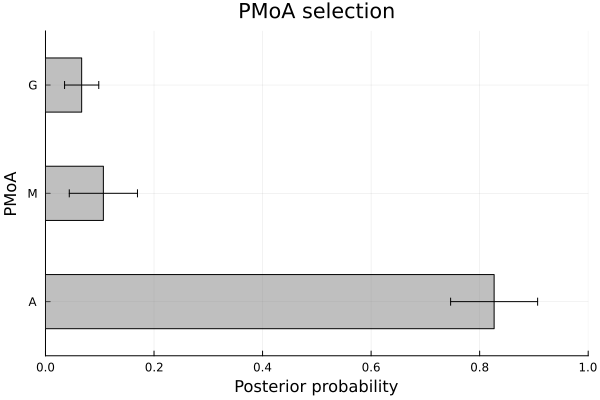

"c:\\Users\\shansul\\Documents\\AmphiDEBResearch-1\\WP02_TKTD\\plots\\Discoglossus_24D_summaries_PMoA_probabilities.png"

In [15]:
ci(x) = quantile(x, 0.75) - quantile(x, 0.25)

plt_probs = @df probs bar(
    :model, :prob, 
    permute = (:y, :x),
    yerrors = [ci(bootstrap_probs_A), ci(bootstrap_probs_M), ci(bootstrap_probs_G)], 
    xlim = (0,3), ylim = (0,1), 
    xlabel = "PMoA", ylabel = "Posterior probability",
    bar_width = 0.5, leg = false, 
    fillcolor = :gray, fillalpha = .5,
    title = "PMoA selection"
    )
display(plt_probs)
savefig(plot(plt_probs, dpi = 300), plotsdir("Discoglossus_24D_summaries_PMoA_probabilities.png"))

## Frequentist model selection

Since all alternative PMoAs have the same number of parameters, 
we perform frequentist model selection simply based on the loss values associated with the best fit of each PMoA. <br>

This indicates the lowest loss for $A$, followed very closesly by $M$. 

In [16]:
vcat(
    @subset(accepted_G, :loss .== minimum(:loss))[:,[:model,:loss]],
    @subset(accepted_M, :loss .== minimum(:loss))[:,[:model,:loss]],
    @subset(accepted_A, :loss .== minimum(:loss))[:,[:model,:loss]]
) |> x-> @transform(x, :loss = round.(:loss, sigdigits = 2))

Row,model,loss
,String,Float64
1,G,0.1
2,M,0.09
3,A,0.087


## Conclusions

- **Frequentist model selection**, i.e. identifiying the best-fitting particle, identifies $A$ as slightly preferable over $M$, and $G$ as least preferable
- **Bayesian model selection**, i.e. computing posterior probabilities of PMoAs, identifies $A$ as the most likely model
- By **visual inspection**, we identify $M$ as the most plausible PMoA


Both frequentist and Bayesian model selection lead to somewhat counter-intuitive results, as they indicate that $A$ is more likely than $M$, whereas visual inspection suggests that $M$ is preferrable.

By combining the outcomes of all three model selection methods, we conclude that $M$ ist most likely, $A$ is less likely but somewhat plausible and $G$ is ruled out. <br>